# Notebook 08 — Runner Clustering (Unsupervised Learning)

**Objective:** Identify runner archetypes in the finisher dataset to enrich the Streamlit app with comparative context and actionable insights.

**Algorithm:** KMeans applied to scaled numerical features (Age, Finish).

**Post-clustering analysis:** Distribution of categorical variables (Gender, Country, Race_Category) and BQ rate per cluster.

**Expected output:** Dataset with an added `cluster` column + narrative characterization of each runner archetype.

In [26]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# Clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paths
RAW_DATA_DIR = Path("../data/raw")
PROCESSED_DATA_DIR = Path("../data/processed")
FIGURES_DIR = Path("../reports/figures")

# Display
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("Setup complete")

Setup complete


## 01 — Data Loading and Cleaning

We load `Results.csv` (one record per runner per race) and apply the same data quality filters used in Notebooks 01 and 03:

- Filter races with `Include == 'Yes'` (same universe as the supervised model)  
- Keep only finishers (`Finish` not null and > 0)  
- Remove outliers: impossible finish times and anomalous ages  

We also load `Races.csv` to include race category, and `BQStandards.csv` to reconstruct the `es_BQ` column (used later in Section 5 to compute BQ rate by cluster).

In [27]:
results = pd.read_csv(RAW_DATA_DIR / "Results.csv")
races = pd.read_csv(RAW_DATA_DIR / "Races.csv")
bq_standards = pd.read_csv(RAW_DATA_DIR / "BQStandards.csv")

print(f"Results: {results.shape}")
print(f"Races:   {races.shape}")
print(f"BQ:      {bq_standards.shape}")

Results: (1760979, 12)
Races:   (762, 8)
BQ:      (22, 3)


### Filter 1: Only Races with `Include == 'Yes'`

We apply the same criterion as in Notebook 01: keep only standard marathons (excluding ultras, cross-country, and atypical events).

We use `Races.csv` to identify which `(Year, Race)` combinations are included, and filter `Results` accordingly.

In [28]:
races_included = races[races["Include"] == "Yes"][["Year", "Race", "Category"]].copy()

# Inner merge: keep only runners from included races
df = results.merge(races_included, on=["Year", "Race"], how="inner")

print(f"After filtering Include == Yes: {df.shape}")
print(f"Unique races: {df['Race'].nunique()}")
print(f"Years: {sorted(df['Year'].unique())}")

After filtering Include == Yes: (1088357, 13)
Unique races: 275
Years: [np.int64(2022), np.int64(2023), np.int64(2024)]


### Filter 2: Valid Finishers and Outlier Cleaning

- `Finish` not null and > 0 → remove DNFs  
- `Finish` between 7,200 and 25,200 seconds (2h–7h) → remove recording errors and extreme walking times  
- `Age` between 12 and 90 → remove impossible age values

In [29]:
n_initial = len(df)

# 1. Valid finishers
df = df[df["Finish"].notna() & (df["Finish"] > 0)].copy()
n_finishers = len(df)

# 2. Realistic finish times (2h - 7h)
df = df[(df["Finish"] >= 7200) & (df["Finish"] <= 25200)].copy()
n_time_ok = len(df)

# 3. Age cleaning: convert to numeric (invalid → NaN) and filter realistic range
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df = df[df["Age"].notna()].copy()
df = df[(df["Age"] >= 12) & (df["Age"] <= 90)].copy()
df["Age"] = df["Age"].astype(int)

n_age_ok = len(df)

print(f"Initial:                 {n_initial:,}")
print(f"After valid finishers:   {n_finishers:,}  ({n_finishers - n_initial:+,})")
print(f"After time filter:       {n_time_ok:,}  ({n_time_ok - n_finishers:+,})")
print(f"After age filter:        {n_age_ok:,}  ({n_age_ok - n_time_ok:+,})")
print(f"\nFinal dataset: {len(df):,} finishers")

Initial:                 1,088,357
After valid finishers:   1,085,412  (-2,945)
After time filter:       1,055,807  (-29,605)
After age filter:        1,047,565  (-8,242)

Final dataset: 1,047,565 finishers


## 02 — Feature Preparation for Clustering

**Features used for clustering:**
- `Age` (runner age)  
- `Finish` (marathon finish time in seconds)  

**Features NOT used for clustering but used in post-analysis:**
- `Gender`, `Country`, `Category`, `es_BQ`  

**Design decisions:**

- `StandardScaler` is applied so that `Age` and `Finish` contribute equally to Euclidean distance.  
- Stratified sampling by `Gender` and `Age_Bracket` (150,000 runners) is used to speed up the K selection process during experimentation. The final model is applied to the full dataset using `predict`.  
- `Country` is excluded from clustering to avoid the US-centric bias dominating cluster formation.  
- `Race_Category_enc` is excluded because it describes the **race**, not the **runner**. Including it would bias clusters toward event types rather than athlete archetypes.

In [30]:
def get_age_bracket(age):
    if age < 35:
        return "Under 35"
    elif age < 40:
        return "35-39"
    elif age < 45:
        return "40-44"
    elif age < 50:
        return "45-49"
    elif age < 55:
        return "50-54"
    elif age < 60:
        return "55-59"
    elif age < 65:
        return "60-64"
    elif age < 70:
        return "65-69"
    elif age < 75:
        return "70-74"
    elif age < 80:
        return "75-79"
    else:
        return "80 and Over"


# Clean Gender: only M/F included in BQ analysis
n_pre = len(df)
df = df[df["Gender"].isin(["M", "F"])].copy()
n_post = len(df)

print(f"Gender filter (M/F only): {n_pre:,} -> {n_post:,} ({n_post - n_pre:+,})")

# Create Age_Bracket
df["Age_Bracket"] = df["Age"].apply(get_age_bracket)

# Merge with BQ standards
df = df.merge(
    bq_standards,
    left_on=["Gender", "Age_Bracket"],
    right_on=["Gender", "Age Bracket"],
    how="left",
)

# Validate no missing standards
n_nan = df["Standard"].isna().sum()
assert n_nan == 0, f"There are {n_nan} runners without assigned Standard"

# Define target variable
df["es_BQ"] = (df["Finish"] <= df["Standard"]).astype(int)

print(f"\nDataset after Gender cleaning + es_BQ creation: {df.shape}")
print(f"BQ rate: {df['es_BQ'].mean() * 100:.2f}%")

print("\nGender distribution:")
print(df.groupby("Gender")["es_BQ"].agg(["count", "mean"]).round(4))

Gender filter (M/F only): 1,047,565 -> 1,046,358 (-1,207)

Dataset after Gender cleaning + es_BQ creation: (1046358, 17)
BQ rate: 13.94%

Gender distribution:
         count    mean
Gender                
F       410500  0.1454
M       635858  0.1355


In [31]:
assert "Age_Bracket" in df.columns
assert "es_BQ" in df.columns

print("Columns OK")
print(df[["Age", "Age_Bracket", "Gender", "Finish", "es_BQ"]].head())

Columns OK
   Age Age_Bracket Gender  Finish  es_BQ
0   33    Under 35      M  7721.0      1
1   26    Under 35      M  7734.0      1
2   33    Under 35      M  7831.0      1
3   32    Under 35      M  7860.0      1
4   31    Under 35      M  7891.0      1


In [32]:
SAMPLE_SIZE = 150_000

# Stratify by Gender and Age_Bracket jointly
df["_strat"] = df["Gender"].astype(str) + "_" + df["Age_Bracket"].astype(str)

# Compute sampling fraction
frac = SAMPLE_SIZE / len(df)

df_sample = (
    df.groupby("_strat", group_keys=False)
      .apply(lambda x: x.sample(frac=frac, random_state=RANDOM_STATE))
      .copy()
)

# Clean auxiliary column (errors='ignore' for pandas compatibility)
df_sample = df_sample.drop(columns=["_strat"], errors="ignore")
df = df.drop(columns=["_strat"], errors="ignore")

print(f"Full dataset: {len(df):,}")
print(f"Sample size:  {len(df_sample):,}")

print("\nGender distribution (full vs sample):")
comparison = pd.DataFrame(
    {
        "full_%": df["Gender"].value_counts(normalize=True) * 100,
        "sample_%": df_sample["Gender"].value_counts(normalize=True) * 100,
    }
).round(2)

print(comparison)

Full dataset: 1,046,358
Sample size:  150,001

Gender distribution (full vs sample):
        full_%  sample_%
Gender                  
M        60.77     60.77
F        39.23     39.23


In [33]:
FEATURES = ["Age", "Finish"]

X = df_sample[FEATURES].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Shape of X: {X.shape}")

print("\nBefore scaling:")
print(f"  Age:    mean={X[:, 0].mean():.2f}, std={X[:, 0].std():.2f}")
print(f"  Finish: mean={X[:, 1].mean():.2f}, std={X[:, 1].std():.2f}")

print("\nAfter scaling:")
print(f"  Age:    mean={X_scaled[:, 0].mean():.4f}, std={X_scaled[:, 0].std():.4f}")
print(f"  Finish: mean={X_scaled[:, 1].mean():.4f}, std={X_scaled[:, 1].std():.4f}")

Shape of X: (150001, 2)

Before scaling:
  Age:    mean=38.04, std=12.88
  Finish: mean=16008.53, std=3454.90

After scaling:
  Age:    mean=-0.0000, std=1.0000
  Finish: mean=0.0000, std=1.0000


## 03 — Optimal Number of Clusters (k)

We evaluate values of k from 2 to 8 using two complementary metrics:

- **Inertia (Elbow Method):** sum of squared distances to the cluster centroids. It always decreases as k increases. We look for the "elbow point" where adding more clusters yields diminishing returns.  
- **Silhouette Score:** measures how well-separated clusters are (range: -1 to 1). Higher values indicate better-defined clusters.

If both methods agree, the decision is straightforward. If not, we rely on business interpretability.

**Note:** Silhouette computation is expensive (O(n²)). To speed up computation, we calculate it on a 30k subsample of the 150k dataset.

In [34]:
from time import time

K_RANGE = range(2, 9)

# Subsample for silhouette (O(n²), does not scale well)
SILHOUETTE_SAMPLE = 30_000
rng = np.random.default_rng(RANDOM_STATE)
sil_idx = rng.choice(len(X_scaled), size=SILHOUETTE_SAMPLE, replace=False)

results = []

for k in K_RANGE:
    t0 = time()

    km = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=RANDOM_STATE,
    )

    labels = km.fit_predict(X_scaled)

    # Silhouette on subsample
    sil = silhouette_score(X_scaled[sil_idx], labels[sil_idx])

    elapsed = time() - t0

    results.append(
        {
            "k": k,
            "inertia": km.inertia_,
            "silhouette": sil,
            "time_s": round(elapsed, 1),
        }
    )

    print(
        f"k={k} | inertia={km.inertia_:>10,.0f} | "
        f"silhouette={sil:.4f} | t={elapsed:.1f}s"
    )

elbow_df = pd.DataFrame(results)

print()
print(elbow_df)

k=2 | inertia=   188,350 | silhouette=0.3479 | t=6.3s
k=3 | inertia=   126,611 | silhouette=0.3587 | t=5.9s
k=4 | inertia=    92,573 | silhouette=0.3550 | t=5.6s
k=5 | inertia=    77,860 | silhouette=0.3302 | t=5.2s
k=6 | inertia=    64,801 | silhouette=0.3493 | t=6.1s
k=7 | inertia=    54,765 | silhouette=0.3459 | t=5.2s
k=8 | inertia=    48,812 | silhouette=0.3401 | t=5.8s

   k        inertia  silhouette  time_s
0  2  188349.519069    0.347942     6.3
1  3  126610.841823    0.358670     5.9
2  4   92573.301898    0.355011     5.6
3  5   77859.906589    0.330248     5.2
4  6   64801.121650    0.349333     6.1
5  7   54764.922982    0.345854     5.2
6  8   48811.781940    0.340098     5.8


### Elbow and Silhouette Visualization

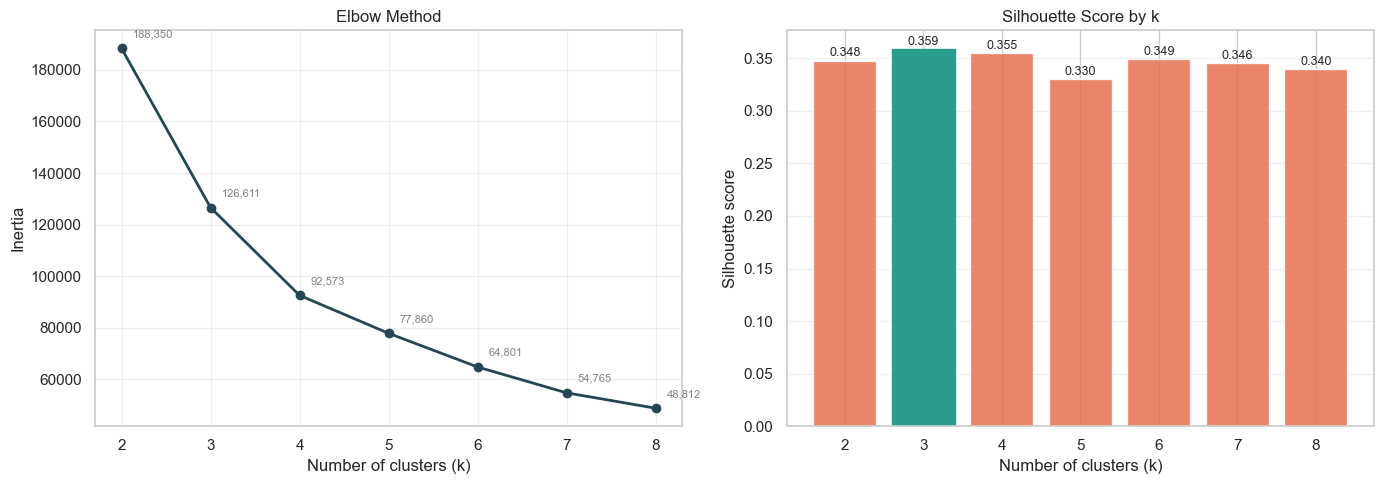


Best k by silhouette: 3 (silhouette=0.3587)


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Elbow method
ax = axes[0]
ax.plot(
    elbow_df["k"],
    elbow_df["inertia"],
    marker="o",
    linewidth=2,
    color="#264653",
)
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Inertia")
ax.set_title("Elbow Method")
ax.grid(True, alpha=0.3)

for _, row in elbow_df.iterrows():
    ax.annotate(
        f'{row["inertia"]:,.0f}',
        xy=(row["k"], row["inertia"]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=8,
        color="gray",
    )

# Panel 2: Silhouette score
ax = axes[1]
bars = ax.bar(
    elbow_df["k"],
    elbow_df["silhouette"],
    color="#E76F51",
    alpha=0.85,
)

# Highlight best k
idx_max = elbow_df["silhouette"].idxmax()
bars[idx_max].set_color("#2A9D8F")
bars[idx_max].set_alpha(1.0)

ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette Score by k")
ax.grid(True, alpha=0.3, axis="y")

for _, row in elbow_df.iterrows():
    ax.annotate(
        f'{row["silhouette"]:.3f}',
        xy=(row["k"], row["silhouette"]),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig(FIGURES_DIR / "13_elbow_silhouette.png", dpi=120, bbox_inches="tight")
plt.show()

print(
    f'\nBest k by silhouette: {elbow_df.loc[idx_max, "k"]} '
    f'(silhouette={elbow_df.loc[idx_max, "silhouette"]:.4f})'
)

## 04 — Final KMeans Training

We train a KMeans model with **k = 4** on the stratified sample of 150k runners.

We then apply the trained model to the **full dataset (1M+ runners)** using `predict()`. This is standard practice in exploratory clustering: `fit` is used to learn centroids from a representative sample, while `predict` assigns each observation in the full population to its nearest cluster.

### Why k = 4

- Silhouette score = 0.355 (very close to the maximum at k=3, difference of only 0.004).  
- Inertia is 27% lower than k=3, indicating that the additional cluster captures meaningful structure.  
- It enables a clearer narrative of four distinct runner archetypes, which is valuable for the Streamlit application.

In [36]:
K_FINAL = 4

kmeans_final = KMeans(
    n_clusters=K_FINAL,
    init="k-means++",
    n_init=10,
    random_state=RANDOM_STATE,
)

# Fit on scaled sample
kmeans_final.fit(X_scaled)

# Predict on sample (for analysis)
df_sample["cluster"] = kmeans_final.predict(X_scaled)

# Predict on full dataset (using same scaler)
X_full = df[FEATURES].values
X_full_scaled = scaler.transform(X_full)
df["cluster"] = kmeans_final.predict(X_full_scaled)

print(f"Model trained with k={K_FINAL}")

print(f"\nCluster distribution in sample ({len(df_sample):,} runners):")
print(df_sample["cluster"].value_counts().sort_index())

print(f"\nCluster distribution in full dataset ({len(df):,} runners):")
print(df["cluster"].value_counts().sort_index())

print("\nCluster proportions in full dataset (%):")
print((df["cluster"].value_counts(normalize=True).sort_index() * 100).round(2))

Model trained with k=4

Cluster distribution in sample (150,001 runners):
cluster
0    34415
1    45859
2    26554
3    43173
Name: count, dtype: int64

Cluster distribution in full dataset (1,046,358 runners):
cluster
0    241101
1    319508
2    185101
3    300648
Name: count, dtype: int64

Cluster proportions in full dataset (%):
cluster
0    23.04
1    30.54
2    17.69
3    28.73
Name: proportion, dtype: float64


### Centroids in Original Scale

The centroids were computed in the scaled feature space. To make them interpretable in real-world terms, we inverse-transform them back to the original scale.

In [37]:
# Inverse-transform centroids
centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(
    centroids_original,
    columns=FEATURES,
)

centroids_df["Age"] = centroids_df["Age"].round(1)
centroids_df["Finish_h"] = (centroids_df["Finish"] / 3600).round(2)

centroids_df["Finish_legible"] = pd.to_timedelta(
    centroids_df["Finish"], unit="s"
).apply(
    lambda x: f"{x.components.hours}h{x.components.minutes:02d}m{x.components.seconds:02d}s"
)

centroids_df.index.name = "cluster"

print("Centroids (original scale):")
print(centroids_df[["Age", "Finish", "Finish_h", "Finish_legible"]])

Centroids (original scale):
          Age        Finish  Finish_h Finish_legible
cluster                                             
0        29.8  19345.601794      5.37       5h22m25s
1        46.3  13844.676907      3.85       3h50m44s
2        53.5  19517.580550      5.42       5h25m17s
3        26.3  13487.127860      3.75       3h44m47s


## 05 — Cluster Characterization

For each cluster we analyze:

1. **Size:** number of runners and percentage of the total dataset  
2. **Numeric statistics:** mean and median values for `Age` and `Finish`  
3. **Gender distribution:** percentage of male and female runners  
4. **Country distribution (Top 5):** to assess whether the US-centric bias affects any cluster  
5. **Race category distribution:** types of races each cluster tends to run  
6. **BQ rate:** the key metric linking the unsupervised clusters with the supervised target  

**Important:** none of these variables were used during clustering. They are used only post-hoc to *describe* the groups discovered by KMeans using only `Age` and `Finish`.

In [38]:
# Mapping cluster_id -> descriptive names (based on observed centroids)
CLUSTER_NAMES = {
    3: "Advanced Young",
    1: "Advanced Veteran",
    0: "Aspiring Young",
    2: "Aspiring Veteran",
}

# Logical order for presentation: advanced first, then aspiring groups
CLUSTER_ORDER = [
    "Advanced Young",
    "Advanced Veteran",
    "Aspiring Young",
    "Aspiring Veteran",
]

df["cluster_name"] = df["cluster"].map(CLUSTER_NAMES)
df_sample["cluster_name"] = df_sample["cluster"].map(CLUSTER_NAMES)

# Ordered categorical for consistent plotting and reporting
df["cluster_name"] = pd.Categorical(
    df["cluster_name"],
    categories=CLUSTER_ORDER,
    ordered=True,
)

df_sample["cluster_name"] = pd.Categorical(
    df_sample["cluster_name"],
    categories=CLUSTER_ORDER,
    ordered=True,
)

print("Cluster labels assigned:")
print(df["cluster_name"].value_counts().sort_index())

Cluster labels assigned:
cluster_name
Advanced Young      300648
Advanced Veteran    319508
Aspiring Young      241101
Aspiring Veteran    185101
Name: count, dtype: int64


### Cluster Summary Table

In [40]:
def fmt_seconds(s):
    """Convert seconds to H:MM:SS format."""
    return pd.to_timedelta(s, unit="s").apply(
        lambda x: f"{x.components.hours}h{x.components.minutes:02d}m{x.components.seconds:02d}s"
    )

# Numerical aggregations
summary = df.groupby("cluster_name", observed=True).agg(
    n=("Age", "count"),
    age_mean=("Age", "mean"),
    age_median=("Age", "median"),
    finish_mean_s=("Finish", "mean"),
    finish_median_s=("Finish", "median"),
    pct_female=("Gender", lambda x: (x == "F").mean() * 100),
    pct_usa=("Country", lambda x: (x == "US").mean() * 100),
    bq_rate=("es_BQ", "mean"),
).round(2)

# Convert times to readable format
summary["finish_mean"] = fmt_seconds(summary["finish_mean_s"])
summary["finish_median"] = fmt_seconds(summary["finish_median_s"])
summary["bq_rate_pct"] = (summary["bq_rate"] * 100).round(2)
summary["pct_total"] = (summary["n"] / summary["n"].sum() * 100).round(2)

# Reorder columns for presentation
summary_display = summary[
    [
        "n",
        "pct_total",
        "age_mean",
        "age_median",
        "finish_mean",
        "finish_median",
        "pct_female",
        "pct_usa",
        "bq_rate_pct",
    ]
].copy()

summary_display.columns = [
    "n",
    "% total",
    "Age mean",
    "Age median",
    "Finish mean",
    "Finish median",
    "% Female",
    "% USA",
    "BQ rate (%)",
]

print("Cluster summary:")
print(summary_display)

Cluster summary:
                       n  % total  Age mean  Age median Finish mean Finish median  % Female  % USA  BQ rate (%)
cluster_name                                                                                                   
Advanced Young    300648    28.73     26.35        27.0    3h44m26s      3h48m11s     34.37  70.37         19.0
Advanced Veteran  319508    30.54     46.32        45.0    3h50m54s      3h52m48s     31.43  65.84         28.0
Aspiring Young    241101    23.04     29.83        30.0    5h22m02s      5h14m25s     51.22  77.23          0.0
Aspiring Veteran  185101    17.69     53.48        52.0    5h25m27s      5h19m34s     44.98  73.09          1.0


### Race Category Distribution by Cluster

Do different clusters tend to prefer marathons of a specific difficulty level?

This helps us understand whether runners self-select into races that match their ability level, or whether all groups converge on the same “headline” races regardless of performance level.

In [41]:
# Cross-tab: cluster vs Race_Category (row-normalized percentages)
cat_tab = pd.crosstab(
    df["cluster_name"],
    df["Category"],
    normalize="index",
) * 100

cat_tab = cat_tab.round(2)

print("Race_Category distribution by cluster (% row-wise):")
print(cat_tab)

Race_Category distribution by cluster (% row-wise):
Category          Boston  Minor  Moderate  Steep  Very Steep
cluster_name                                                
Advanced Young     31.86  40.77     10.37  11.99        5.01
Advanced Veteran   40.21  29.63      9.76  11.56        8.83
Aspiring Young      9.20  70.08      8.14   9.56        3.02
Aspiring Veteran   20.36  54.02      8.90  11.15        5.56


In [42]:
# Full mapping: all non-ISO2 country codes → ISO-2 format
country_mapping = {
    # Standard ISO-3 codes (common)
    "USA": "US", "GBR": "GB", "CAN": "CA", "FRA": "FR", "AUS": "AU",
    "GER": "DE", "ITA": "IT", "IRL": "IE", "MEX": "MX", "RUS": "RU",
    "ESP": "ES", "JPN": "JP", "ARG": "AR", "TWN": "TW", "DEN": "DK",
    "SWE": "SE", "AUT": "AT", "BRA": "BR", "SIN": "SG", "BEL": "BE",
    "HKG": "HK", "POL": "PL", "NZL": "NZ", "NOR": "NO", "SVK": "SK",
    "POR": "PT", "CZE": "CZ", "IND": "IN", "EST": "EE", "FIN": "FI",
    "CHN": "CN", "MAR": "MA", "TUR": "TR", "ISR": "IL", "PHI": "PH",
    "THA": "TH", "COL": "CO", "ROU": "RO", "HUN": "HU", "KEN": "KE",
    "LTU": "LT", "ISL": "IS", "UKR": "UA", "VIE": "VN", "KOR": "KR",
    "PER": "PE", "VEN": "VE", "PAN": "PA", "TAN": "TZ", "ECU": "EC",
    "DOM": "DO", "CRO": "HR", "ETH": "ET", "LUX": "LU", "EGY": "EG",
    "UGA": "UG", "SRB": "RS", "BOL": "BO",

    # Less common ISO-3 codes
    "MGL": "MN", "ERI": "ER", "GRE": "GR", "JOR": "JO", "CRC": "CR",
    "IRI": "IR", "TRI": "TT", "KAZ": "KZ", "PUR": "PR", "LIE": "LI",
    "ALG": "DZ", "LIB": "LB", "PAK": "PK", "BAN": "BD", "ZIM": "ZW",
    "GEO": "GE", "GHA": "GH", "ANG": "AO", "AZE": "AZ", "NEP": "NP",
    "BAH": "BS", "NCA": "NI", "TPE": "TW", "ARM": "AM", "KSA": "SA",
    "KGZ": "KG", "LBA": "LY", "MLT": "MT", "MDA": "MD", "MON": "MC",
    "SEN": "SN", "SRI": "LK", "TOG": "TG", "TRN": "TT", "TUN": "TN",
    "BDI": "BI", "COD": "CD", "MAC": "MO", "CIV": "CI", "CAF": "CF",
    "VIN": "VC", "MOZ": "MZ", "COM": "KM", "DMA": "DM", "DJI": "DJ",

    # Non-standard codes
    "NED": "NL", "SUI": "CH", "INA": "ID", "RSA": "ZA", "CHI": "CL",
    "BUR": "UNKNOWN",

    # Extra mappings
    "LAT": "LV", "BRN": "BH", "MAS": "MY", "BUL": "BG", "FRO": "FO",
    "PAR": "PY", "QAT": "QA", "SWZ": "SZ", "GUA": "GT", "KOS": "XK",
    "ESA": "SV", "SLO": "SI", "BLR": "BY", "CYP": "CY", "BIH": "BA",
    "MDV": "MV", "URU": "UY", "HON": "HN", "GIB": "GI", "MKD": "MK",
    "ZAM": "ZM", "GRL": "GL", "SUD": "SD", "CHA": "TD", "BRU": "BN",
    "AND": "AD", "IRQ": "IQ", "ALB": "AL", "MRI": "MU", "PLE": "PS",
    "BER": "BM", "GUM": "GU", "NGR": "NG", "JAM": "JM", "CUB": "CU",
    "GRN": "GD", "AFG": "AF", "HAI": "HT", "SUR": "SR", "LCA": "LC",
    "NAM": "NA", "UZB": "UZ", "SYR": "SY", "MNE": "ME", "CMR": "CM",
    "OMN": "OM", "TKM": "TM", "BEN": "BJ", "SMR": "SM", "PNG": "PG",
    "KUW": "KW", "CPV": "CV", "BIZ": "BZ", "MAD": "MG", "GUY": "GY",
    "UAE": "AE", "CAM": "KH", "BOT": "BW", "LAO": "LA", "PLW": "PW",
    "RWA": "RW", "MAW": "MW",
}

# Apply mapping to both dataframes (df and df_sample share same logic)
for d in [df, df_sample]:
    d["Country"] = d["Country"].replace(country_mapping)
    d["Country"] = d["Country"].fillna("UNKNOWN")

# Final validation on full dataset
remaining_3letter = df[df["Country"].str.len() == 3]["Country"].unique()

if len(remaining_3letter) > 0:
    print(f"WARNING: remaining 3-letter codes: {remaining_3letter}")
    print(
        f"Total affected runners: {df[df['Country'].isin(remaining_3letter)].shape[0]}"
    )
else:
    print("OK: all country codes are ISO-2 or UNKNOWN")

print(f"\nUnique countries after normalization: {df['Country'].nunique()}")

print("\nTop 15 countries in full dataset:")
print(df["Country"].value_counts().head(15))

OK: all country codes are ISO-2 or UNKNOWN

Unique countries after normalization: 197

Top 15 countries in full dataset:
Country
US         755960
GB         116847
CA          45366
DE          25264
UNKNOWN     12828
MX          10914
JP           7082
FR           5845
BR           5696
AU           5337
IT           5055
IE           4252
ES           3654
NL           3576
PL           2501
Name: count, dtype: int64


In [43]:
MIN_COUNTRY_COUNT = 500

country_counts = df["Country"].value_counts()
countries_to_keep = set(country_counts[country_counts >= MIN_COUNTRY_COUNT].index)

# UNKNOWN is never kept as a meaningful category
countries_to_keep.discard("UNKNOWN")

for d in [df, df_sample]:
    d["Country_grouped"] = d["Country"].where(
        d["Country"].isin(countries_to_keep),
        other="OTHER",
    )

print(f"Countries kept as individual categories: {len(countries_to_keep)}")

print("\nDistribution in full dataset:")
print(df["Country_grouped"].value_counts())

print(
    f"\n% in OTHER: {(df['Country_grouped'] == 'OTHER').mean() * 100:.2f}%"
)

Countries kept as individual categories: 38

Distribution in full dataset:
Country_grouped
US       755960
GB       116847
CA        45366
DE        25264
OTHER     22619
MX        10914
JP         7082
FR         5845
BR         5696
AU         5337
IT         5055
IE         4252
ES         3654
NL         3576
PL         2501
TH         1979
CN         1962
DK         1923
CO         1842
IN         1824
NO         1577
BE         1503
SE         1387
AR         1329
HK         1061
RU          811
CH          801
TW          792
PE          792
SU          788
AT          774
ID          767
VE          765
KR          733
NZ          708
UA          641
FI          597
EC          526
DO          508
Name: count, dtype: int64

% in OTHER: 2.16%


### Top 5 Countries by Cluster

In [44]:
print("Top 5 countries by cluster (% within cluster):")
print("=" * 70)

for cluster_name in CLUSTER_ORDER:
    sub = df[df["cluster_name"] == cluster_name]

    top5 = (
        sub["Country_grouped"]
        .value_counts(normalize=True)
        * 100
    ).head(5).round(2)

    print(f"\n{cluster_name} (n={len(sub):,})")

    for country, pct in top5.items():
        print(f"  {country:<10} {pct:>6.2f}%")

Top 5 countries by cluster (% within cluster):

Advanced Young (n=300,648)
  US          71.32%
  GB          12.30%
  CA           6.04%
  OTHER        2.05%
  DE           1.93%

Advanced Veteran (n=319,508)
  US          67.30%
  GB          10.23%
  CA           4.55%
  DE           3.56%
  OTHER        2.97%

Aspiring Young (n=241,101)
  US          78.09%
  GB          11.75%
  CA           3.34%
  OTHER        1.44%
  DE           1.17%

Aspiring Veteran (n=185,101)
  US          74.69%
  GB          10.18%
  DE           2.86%
  CA           2.49%
  OTHER        1.88%


## 06 — Visualizations

We use four plots to support the narrative:

1. **Age vs Finish scatter plot** colored by cluster (direct interpretability).  
2. **2D PCA projection** (visualization of the scaled feature space).  
3. **BQ rate by cluster** (key insight of the analysis).  
4. **Gender distribution by cluster** (demographic bias analysis).

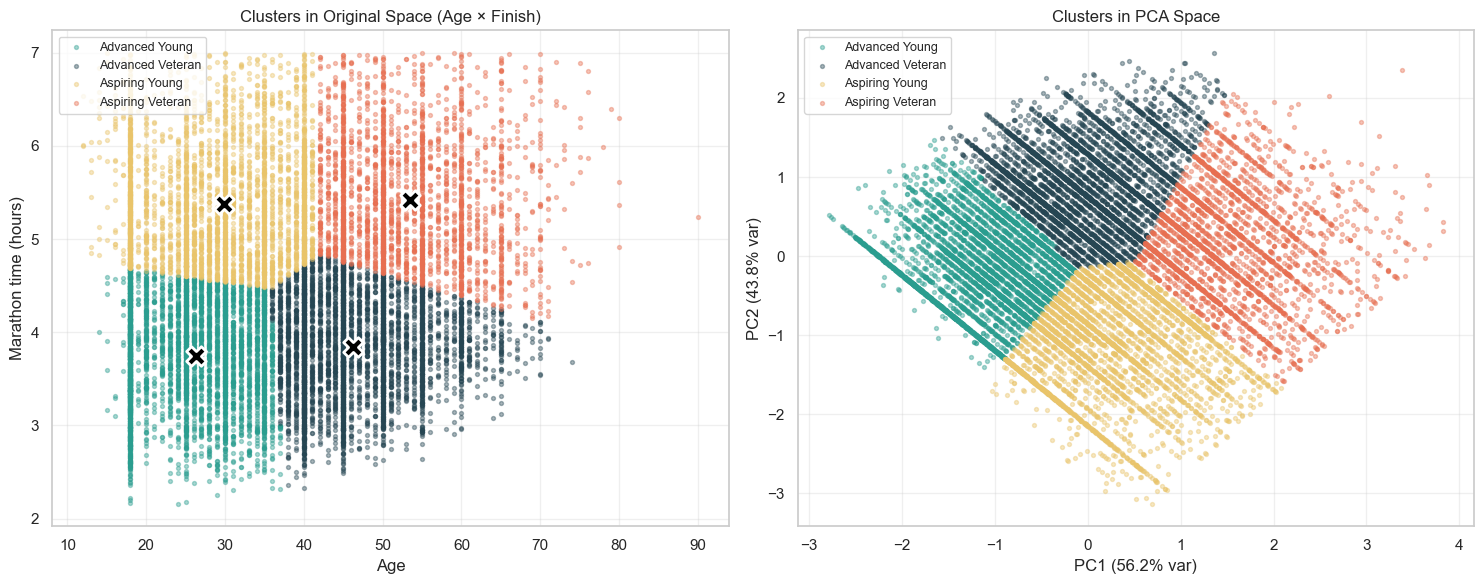

In [45]:
# Subsample to avoid overcrowded scatter plots (150k points is not readable)
PLOT_SAMPLE = 15_000
plot_idx = rng.choice(len(df_sample), size=PLOT_SAMPLE, replace=False)
df_plot = df_sample.iloc[plot_idx].copy()

palette = {
    "Advanced Young": "#2A9D8F",
    "Advanced Veteran": "#264653",
    "Aspiring Young": "#E9C46A",
    "Aspiring Veteran": "#E76F51",
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# -------------------------
# Panel 1: Age vs Finish
# -------------------------
ax = axes[0]

for name in CLUSTER_ORDER:
    sub = df_plot[df_plot["cluster_name"] == name]
    ax.scatter(
        sub["Age"],
        sub["Finish"] / 3600,
        c=palette[name],
        label=name,
        alpha=0.4,
        s=8,
    )

# Centroids
centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

for cluster_id, name in CLUSTER_NAMES.items():
    c = centroids_original[cluster_id]
    ax.scatter(
        c[0],
        c[1] / 3600,
        c="black",
        s=200,
        marker="X",
        edgecolor="white",
        linewidth=2,
        zorder=5,
    )

ax.set_xlabel("Age")
ax.set_ylabel("Marathon time (hours)")
ax.set_title("Clusters in Original Space (Age × Finish)")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)

# -------------------------
# Panel 2: PCA projection
# -------------------------
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled[plot_idx])

ax = axes[1]

for name in CLUSTER_ORDER:
    mask = df_plot["cluster_name"].values == name
    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=palette[name],
        label=name,
        alpha=0.4,
        s=8,
    )

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("Clusters in PCA Space")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "14_clusters_scatter_pca.png", dpi=120, bbox_inches="tight")
plt.show()

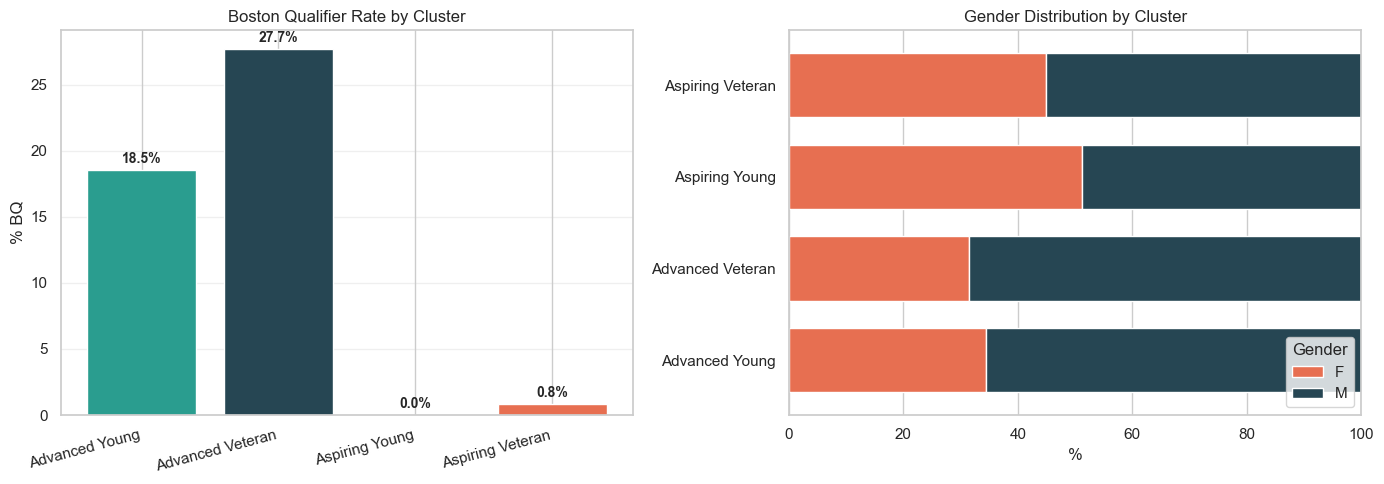

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -------------------------
# Panel 1: BQ rate by cluster
# -------------------------
ax = axes[0]

bq_rates = df.groupby("cluster_name", observed=True)["es_BQ"].mean() * 100

bars = ax.bar(
    range(len(CLUSTER_ORDER)),
    [bq_rates[name] for name in CLUSTER_ORDER],
    color=[palette[n] for n in CLUSTER_ORDER],
)

ax.set_xticks(range(len(CLUSTER_ORDER)))
ax.set_xticklabels(CLUSTER_ORDER, rotation=15, ha="right")
ax.set_ylabel("% BQ")
ax.set_title("Boston Qualifier Rate by Cluster")
ax.grid(True, alpha=0.3, axis="y")

for i, name in enumerate(CLUSTER_ORDER):
    ax.text(
        i,
        bq_rates[name] + 0.5,
        f"{bq_rates[name]:.1f}%",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

# -------------------------
# Panel 2: Gender distribution by cluster
# -------------------------
ax = axes[1]

gender_dist = (
    pd.crosstab(df["cluster_name"], df["Gender"], normalize="index") * 100
)
gender_dist = gender_dist.loc[CLUSTER_ORDER]

gender_dist.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=["#E76F51", "#264653"],
    width=0.7,
)

ax.set_xlabel("%")
ax.set_ylabel("")
ax.set_title("Gender Distribution by Cluster")
ax.legend(title="Gender", loc="lower right")
ax.set_xlim(0, 100)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "15_clusters_bq_gender.png", dpi=120, bbox_inches="tight")
plt.show()

## 07 — Conclusions and Artifact Saving

### Key Findings

1. **Four runner archetypes defined by age × performance**, rather than a single linear performance hierarchy:
   - Advanced Young (28.7%): 26 years, 3h44, 19% BQ rate  
   - Advanced Veteran (30.5%): 46 years, 3h50, **28% BQ rate** (highest rate)  
   - Aspiring Young (23.0%): 30 years, 5h22, 0% BQ rate  
   - Aspiring Veteran (17.7%): 53 years, 5h25, 1% BQ rate  

2. **Age is as influential as performance for BQ qualification:** Advanced Veterans have a ~9 percentage point higher BQ rate than Advanced Young runners despite being ~6 minutes slower. This reflects age-adjusted qualification standards.

3. **Clear boundary between Aspiring and Advanced runners:** BQ rate jumps from ~0–1% to ~19%+. Being in the right performance cluster is a prerequisite before BQ becomes realistic.

4. **Advanced Veterans are the most international group** (~33% non-US): experienced runners who tend to travel to major US marathons.

5. **Gender imbalance:** women are overrepresented in Aspiring clusters. This reflects participation patterns rather than performance differences.

---

### Business Application

The Streamlit app will combine:

- **Individual prediction (supervised model from N07):** “Your BQ probability is X%”  
- **Cluster context (this notebook):** “You belong to cluster Y. Z% of runners in your group qualify”  
- **Actionable insight:** if the runner improves their time to T, they would move into the next cluster

---

### Limitations

- The true elite cluster (sub-2h30 runners) is not explicitly separated due to extremely low representation (<0.1% of the dataset).  
- Strong US-centric bias (~70–78% per cluster), inherited from the original dataset.  
- Only binary gender (M/F) is included due to compatibility with BQ standards.

In [47]:
import joblib

ARTIFACTS_DIR = Path("../models/clustering")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# Save model and scaler
joblib.dump(kmeans_final, ARTIFACTS_DIR / "kmeans_final.joblib")
joblib.dump(scaler, ARTIFACTS_DIR / "scaler_clustering.joblib")

# Save metadata: names, order, interpretable centroids
metadata = {
    "k": K_FINAL,
    "features": FEATURES,
    "cluster_names": CLUSTER_NAMES,
    "cluster_order": CLUSTER_ORDER,
    "centroids_original": centroids_df.to_dict(orient="index"),
    "silhouette": float(
        elbow_df.loc[elbow_df["k"] == K_FINAL, "silhouette"].iloc[0]
    ),
    "n_train_sample": len(df_sample),
    "n_full_dataset": len(df),
}

joblib.dump(metadata, ARTIFACTS_DIR / "cluster_metadata.joblib")

# Save dataset with cluster assignments (for downstream analysis and app)
output_cols = [
    "Year",
    "Race",
    "Country",
    "Country_grouped",
    "Gender",
    "Age",
    "Age_Bracket",
    "Finish",
    "Standard",
    "es_BQ",
    "Category",
    "cluster",
    "cluster_name",
]

df_export = df[output_cols].copy()
df_export["cluster_name"] = df_export["cluster_name"].astype(str)

df_export.to_parquet(
    PROCESSED_DATA_DIR / "finishers_with_clusters.parquet",
    index=False,
)

print("Artifacts saved:")
print(f"  kmeans_final.joblib       ({ARTIFACTS_DIR})")
print(f"  scaler_clustering.joblib  ({ARTIFACTS_DIR})")
print(f"  cluster_metadata.joblib   ({ARTIFACTS_DIR})")
print(f"  finishers_with_clusters.parquet ({PROCESSED_DATA_DIR})")

Artifacts saved:
  kmeans_final.joblib       (../models/clustering)
  scaler_clustering.joblib  (../models/clustering)
  cluster_metadata.joblib   (../models/clustering)
  finishers_with_clusters.parquet (../data/processed)
